# Sentiment Analysis and Churn Prediction for Tunisian Telecom Reviews

This notebook documents the process of analyzing customer reviews for Tunisian telecom providers. The goal is to predict customer sentiment (Positive or Negative) based on their reviews and identify potential churn drivers. Below, we explain each step of the workflow, from data loading to model evaluation, and how the predictions are made.

---

## 1. Data Loading and Exploration

We start by loading the cleaned dataset from the intermediate folder:

```python
file_path = '../data/02_intermediate/tunisian_telco_reviews_cleaned.csv'
df = pd.read_csv(file_path)
```

- **Dataset Overview**: The dataset contains customer reviews in mixed languages (French, Arabic, and Tunisian Derja). It includes columns such as `content_cleaned` (preprocessed review text), `score` (rating), and `sentiment` (Positive/Negative/Neutral).
- **Shape**: The dataset has 20,495 rows and 8 columns.
- **Purpose**: This dataset will be used to train and evaluate a sentiment analysis model.

---

## 2. Data Filtering and Preprocessing

### Removing Neutral Reviews
Neutral reviews (3-star ratings) are excluded to focus on binary sentiment classification:

```python
df_binary = df[df['score'] != 3].copy()
```

### Mapping Sentiment Labels
The `score` column is mapped to binary sentiment labels:
- **1-2 Stars** → `Negative`
- **4-5 Stars** → `Positive`

```python
def map_binary_sentiment(score):
    if score <= 2:
        return 'Negative'
    else:
        return 'Positive'

df_binary['sentiment'] = df_binary['score'].apply(map_binary_sentiment)
```

### Splitting Data
The dataset is split into training and testing sets:
- **80% Training**: Used to train the model.
- **20% Testing**: Used to evaluate the model's performance.

```python
X = df_binary['content_cleaned']
y = df_binary['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

---

## 3. Model Training and Prediction

### Building the Pipeline
We use a `Pipeline` to streamline the process:
1. **TF-IDF Vectorizer**: Converts text into numerical features by analyzing word frequency and importance.
2. **Logistic Regression**: A simple yet effective classifier for binary sentiment analysis.

```python
pipeline_binary = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)), 
    ('clf', LogisticRegression(solver='lbfgs', random_state=42))
])
```

### Training the Model
The pipeline is trained on the `X_train` and `y_train` data:

```python
pipeline_binary.fit(X_train, y_train)
```

### Making Predictions
The trained model predicts sentiment for the test set:

```python
y_pred = pipeline_binary.predict(X_test)
```

---

## 4. Model Evaluation

### Classification Report
The classification report provides metrics such as precision, recall, and F1-score for both classes (Positive and Negative):

```python
print(classification_report(y_test, y_pred))
```

### Confusion Matrix
The confusion matrix visualizes the model's performance by showing:
- **True Positives (TP)**: Correctly predicted Positive reviews.
- **True Negatives (TN)**: Correctly predicted Negative reviews.
- **False Positives (FP)**: Negative reviews misclassified as Positive.
- **False Negatives (FN)**: Positive reviews misclassified as Negative.

```python
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
```

---

## 5. Accuracy and Generalization

### Training vs Testing Accuracy
The model's accuracy is calculated for both the training and testing sets:

```python
train_acc = pipeline_binary.score(X_train, y_train)
test_acc = pipeline_binary.score(X_test, y_test)
```

- **Training Accuracy**: 92.46%
- **Testing Accuracy**: 88.74%
- **Gap**: 3.72% (indicating good generalization).

---

## 6. Error Analysis

### Identifying Mistakes
We analyze the reviews where the model made incorrect predictions:

```python
results_df = X_test.to_frame(name='Review Text')
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred

mistakes = results_df[results_df['Actual'] != results_df['Predicted']]
```

### False Positives and False Negatives
- **False Positives**: Reviews predicted as Positive but are actually Negative.
- **False Negatives**: Reviews predicted as Negative but are actually Positive.

```python
false_positives = mistakes[mistakes['Predicted'] == 'Positive']
false_negatives = mistakes[mistakes['Predicted'] == 'Negative']
```

We inspect a few examples to understand why the model failed:

```python
def show_mistakes(df, error_type, num=5):
    sample = df.sample(min(num, len(df)), random_state=42)
    for i, row in sample.iterrows():
        print(f"📝 Review:  {row['Review Text']}")
        print(f"❌ Model said: {row['Predicted']}")
        print(f"✅ Truth was:  {row['Actual']}")
```

---

## 7. How the Model Predicts Sentiment

The model uses the **TF-IDF Vectorizer** to analyze the text:
- **TF (Term Frequency)**: How often a word appears in a review.
- **IDF (Inverse Document Frequency)**: How unique a word is across all reviews.

The **Logistic Regression Classifier** then assigns probabilities to each class (Positive or Negative) based on the extracted features. The class with the highest probability is chosen as the prediction.

---

## 8. Summary

- **Objective**: Predict customer sentiment (Positive/Negative) from mixed-language reviews.
- **Pipeline**: Combines TF-IDF vectorization and Logistic Regression for efficient classification.
- **Performance**: Achieved 88.74% accuracy on the test set with a small generalization gap.
- **Error Analysis**: Helps identify areas for improvement, such as handling mixed-language nuances or rare words.

This notebook demonstrates a robust workflow for sentiment analysis, providing valuable insights into customer feedback for Tunisian telecom providers.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data from the intermediate folder
file_path = '../data/02_intermediate/tunisian_telco_reviews_cleaned.csv'
df = pd.read_csv(file_path)

print(f"Data Loaded. Shape: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Data Loaded. Shape: (20607, 7)
Columns: ['content', 'score', 'at', 'thumbsUpCount', 'company', 'source', 'content_cleaned']


,content,score,at,thumbsUpCount,company,source,content_cleaned
0,سراق محدش يستعمله,1,2025-12-03 12:29:20,0,Orange,GooglePlay,سراق محدش يستعمله
1,des problèmes de démarrage répétitifs malgré l...,1,2025-11-29 17:39:35,0,Orange,GooglePlay,des problèmes de démarrage répétitifs malgré l...
2,"Pretty sûre not a good experience, garbage",1,2025-11-25 15:28:43,0,Orange,GooglePlay,pretty sûre not a good experience garbage
3,Je suis très satisfait,5,2025-11-25 14:58:11,0,Orange,GooglePlay,je suis très satisfait
4,bien,4,2025-11-22 23:32:20,0,Orange,GooglePlay,bien


# Training the models with 3 sentiments (including the neutre)

In [29]:
# --- FIX: Drop Empty Rows First ---
# Remove rows where content_cleaned is NaN (missing)
df = df.dropna(subset=['content_cleaned'])

# Ensure all data is treated as string (text), not numbers
df['content_cleaned'] = df['content_cleaned'].astype(str)

print(f"Rows after removing NaNs: {len(df)}")

# --- CONFIGURATION ---
TEXT_COL = 'content_cleaned' 

# 1. Map Scores to Sentiments
def map_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['score'].apply(map_sentiment)

# 2. Define X and y
X = df[TEXT_COL]
y = df['sentiment']

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("-" * 30)
print(f"Training on {len(X_train)} reviews.")
print(f"Testing on {len(X_test)} reviews.")

Rows after removing NaNs: 20496
------------------------------
Training on 16396 reviews.
Testing on 4100 reviews.


Training Balanced Model...
Evaluating...
              precision    recall  f1-score   support

    Negative       0.85      0.82      0.84      1533
     Neutral       0.14      0.24      0.18       175
    Positive       0.88      0.86      0.87      2392

    accuracy                           0.82      4100
   macro avg       0.63      0.64      0.63      4100
weighted avg       0.84      0.82      0.83      4100



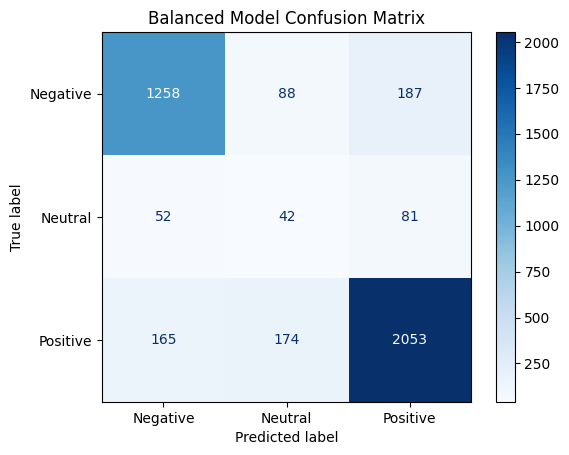

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Build Pipeline with "Balanced" weights
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)), 
    # CHANGED: solver='lbfgs' (fixes warning) and class_weight='balanced' (helps Neutrals)
    ('clf', LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42))
])

# 2. Train
print("Training Balanced Model...")
baseline_pipeline.fit(X_train, y_train)

# 3. Predict
print("Evaluating...")
y_pred = baseline_pipeline.predict(X_test)

# 4. Report
print(classification_report(y_test, y_pred))

# 5. Visualise
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Balanced Model Confusion Matrix")
plt.show()

# Training the models with just 2 sentiments (removed neutre)
> binary problem

In [31]:
from sklearn.model_selection import train_test_split

# --- 1. Filter Data (Remove Neutrals) ---
# Keep only reviews that are NOT 3 stars
df_binary = df[df['score'] != 3].copy()

# Fix NaNs just in case (cleaning step safety)
df_binary = df_binary.dropna(subset=['content_cleaned'])
df_binary['content_cleaned'] = df_binary['content_cleaned'].astype(str)

# --- 2. Map Target (Binary) ---
# 1-2 Stars -> Negative
# 4-5 Stars -> Positive
def map_binary_sentiment(score):
    if score <= 2:
        return 'Negative'
    else:
        return 'Positive'

df_binary['sentiment'] = df_binary['score'].apply(map_binary_sentiment)

# --- 3. Split Data ---
X = df_binary['content_cleaned']
y = df_binary['sentiment']

# 80% Train, 20% Test, Stratified to keep the balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Original reviews: {len(df)}")
print(f"Binary reviews (No Neutrals): {len(df_binary)}")
print("-" * 30)
print(f"Training on {len(X_train)} reviews.")
print(f"Testing on {len(X_test)} reviews.")

Original reviews: 20496
Binary reviews (No Neutrals): 19622
------------------------------
Training on 15697 reviews.
Testing on 3925 reviews.


Training Binary Model...
Evaluating...

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.82      0.85      1533
    Positive       0.89      0.93      0.91      2392

    accuracy                           0.89      3925
   macro avg       0.89      0.88      0.88      3925
weighted avg       0.89      0.89      0.89      3925



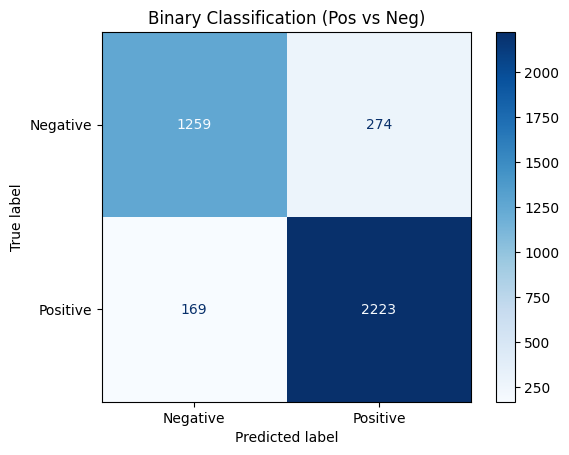

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Build Pipeline
# We stick to the standard solver since we only have 2 classes now
pipeline_binary = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)), 
    ('clf', LogisticRegression(solver='lbfgs', random_state=42))
])

# 2. Train (Fit)
print("Training Binary Model...")
pipeline_binary.fit(X_train, y_train)

# 3. Evaluate
print("Evaluating...")
y_pred = pipeline_binary.predict(X_test)

# 4. Results
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualise Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Binary Classification (Pos vs Neg)")
plt.show()

In [33]:
# Calculate accuracy on the Training set (the data it studied)
train_acc = pipeline_binary.score(X_train, y_train)

# Calculate accuracy on the Test set (the exam)
test_acc = pipeline_binary.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

# Check the gap
gap = train_acc - test_acc
print(f"Gap: {gap:.4f}")

if gap > 0.10:
    print("Warning: Possible Overfitting (Gap > 10%)")
elif gap < 0:
    print("Warning: Testing is better than Training? (Rare, usually means data mismatch)")
else:
    print("✅ Good! The model generalizes well.")

Training Accuracy: 0.9252
Testing Accuracy:  0.8871
Gap: 0.0381
✅ Good! The model generalizes well.


In [34]:
import pandas as pd

# 1. Create a Results Table
# We pull the text from X_test and the labels from y_test/y_pred
results_df = X_test.to_frame(name='Review Text')
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred

# 2. Filter for Mistakes
mistakes = results_df[results_df['Actual'] != results_df['Predicted']]

print(f"Total Mistakes: {len(mistakes)} out of {len(X_test)} test reviews.")

# --- INSPECTION FUNCTION ---
def show_mistakes(df, error_type, num=5):
    print(f"\n=== {error_type} ===")
    if len(df) == 0:
        print("No errors of this type found!")
        return
        
    # Sample random rows to look at
    sample = df.sample(min(num, len(df)), random_state=42)
    
    for i, row in sample.iterrows():
        print(f"📝 Review:  {row['Review Text']}")
        print(f"❌ Model said: {row['Predicted']}")
        print(f"✅ Truth was:  {row['Actual']}")
        print("-" * 50)

# 3. False Positives: Model said "Positive", but it was actually "Negative"
# (The model missed the anger)
false_positives = mistakes[mistakes['Predicted'] == 'Positive']
show_mistakes(false_positives, "FALSE POSITIVES (Model was too Optimistic)")

# 4. False Negatives: Model said "Negative", but it was actually "Positive"
# (The model missed the praise)
false_negatives = mistakes[mistakes['Predicted'] == 'Negative']
show_mistakes(false_negatives, "FALSE NEGATIVES (Model was too Pessimistic)")

Total Mistakes: 443 out of 3925 test reviews.

=== FALSE POSITIVES (Model was too Optimistic) ===
📝 Review:  sorreq yhebou ynahiou loffre bonus bessif
❌ Model said: Positive
✅ Truth was:  Negative
--------------------------------------------------
📝 Review:  z c wg
❌ Model said: Positive
✅ Truth was:  Negative
--------------------------------------------------
📝 Review:  aucunes possibilités d accessibilité
❌ Model said: Positive
✅ Truth was:  Negative
--------------------------------------------------
📝 Review:  fausse information
❌ Model said: Positive
✅ Truth was:  Negative
--------------------------------------------------
📝 Review:  oui makech qada tati fi elkdwat
❌ Model said: Positive
✅ Truth was:  Negative
--------------------------------------------------

=== FALSE NEGATIVES (Model was too Pessimistic) ===
📝 Review:  suis fan de votre service on peux colaboré ce service vraiment vous êtes les meilleurs
❌ Model said: Negative
✅ Truth was:  Positive
----------------------------

# The "Keyword" Trap (False Positives)

### Example 1:
- **Review**: "...loffre bonus bessif"
- **Why it failed**: The model identified the word "bonus," which is typically associated with positive sentiment. However, it missed the context where "bessif" (meaning "by force" or "reluctantly") negates the positivity. TF-IDF focuses on word frequency and lacks the ability to understand context.

### Example 2:
- **Review**: "shira2 mjawharat... diamonds..."
- **Why it failed**: The model recognized "jewels" and "diamonds," which are often linked to positive reviews. However, it overlooked the negation "mيوصلش" (didn't arrive) due to its rare spelling or the model's inability to grasp sentence structure.

---

# The "Rare Word" Problem

### Example:
- **Review**: "application pertinante"
- **Why it failed**: The word "pertinante" is formal French, while the dataset primarily contains informal Arabizi. The model likely never encountered this word or associated "application" with complaints (e.g., "application is slow"), leading to a misclassification as Negative.

---

# Data Noise

### Example:
- **Review**: "khalil"
- **Why it failed**: This is just a person's name. In the training data, "Bravo Khalil" (Positive) might have been present, causing the model to associate "Khalil" with positive sentiment, even when the context is unclear.

---
For a Bag-of-Words model (TF-IDF + Logistic Regression), an 88% accuracy is likely the ceiling

In [27]:
import joblib

# 1. Choose the file name
model_filename = '../models/sentiment_model.pkl'

# 2. Save the pipeline (This saves both the TF-IDF vocabulary AND the Logistic Regression model)
joblib.dump(pipeline_binary, model_filename)

print(f"✅ Model saved successfully as '{model_filename}'")
print("You can now load this file in any other Python script to make predictions!")

✅ Model saved successfully as '../models/sentiment_model.pkl'
You can now load this file in any other Python script to make predictions!
